---
title: "MAGMA: From Variants to Genes to Tissues"
---



::: {.callout-important}
### Before You Start

This notebook is **self-contained**: it starts from the raw ADHD summary
statistics file and takes you all the way to tissue enrichment. You need

- the summary statistics: `ADHD2022_iPSYCH_deCODE_PGC.meta.gz`
- the three reference datasets in `reference_data/` (unzipped, see below)
- access to MAGMA on the course server
:::

::: {.callout-tip}
### How the Code in This Session Works

MAGMA is a **command-line program**, not an R package. So this notebook
alternates between two kinds of chunk:

- **Bash chunks**: the actual MAGMA commands. These are marked `eval = FALSE`:
  you copy them into a terminal on the course server and run them there.
- **R chunks**: read the MAGMA output files back in, tabulate and plot them.
  These are set to run **only if the output file exists**, so the notebook knits
  cleanly before you have run anything. Once a MAGMA step finishes, re-knit and
  the corresponding figures appear.

Work through in order: read the bash chunk, run it in the terminal, wait, then
run the R chunk that reads its output.
:::

## Why Gene-Level Analysis?

::: {.callout-tip}
A GWAS gives you a Manhattan plot and a list of lead SNPs. That list is hard to
act on: the lead SNP is usually intergenic, it is significant only because of LD
with something unknown, and thousands of genuinely causal variants sit just below
5 × 10⁻⁸ and are invisible. Gene-level analysis reframes the question from
*"which variant?"* to *"which gene?"* and *"which tissue?"*, questions you can
follow up in the lab.
:::

### Learning Objectives

After this session you will be able to:

- Explain what MAGMA aggregates and why LD makes that non-trivial
- Prepare MAGMA input files and choose the correct sample size for a case-control GWAS
- Run all three MAGMA steps and describe what each reference file contributes
- Interpret `.genes.out` and `.gsa.out`, applying the correct multiple-testing correction to each
- Explain why tissue enrichment must be conditioned on average expression, and what happens if it is not
- Recognise the main confounders: gene size, gene density, and the MHC region

### The workflow

MAGMA (**M**ulti-marker **A**nalysis of **G**eno**M**ic **A**nnotation, de Leeuw
et al. 2015) is a sequence of three commands. We prepare its input first, then
run them in order, each consuming the output of the one before.

```{mermaid}
%%| fig-align: center
flowchart LR
  A["<b>Step 1 - Prepare</b><br>QC the summary statistics in R<br>snp_loc.txt + pval.txt"]
  B["<b>Step 2 - Annotate</b><br>Assign each SNP to a gene<br>.genes.annot"]
  C["<b>Step 3 - Gene analysis</b><br>One p-value per gene, LD-corrected<br>.genes.out + .genes.raw"]
  D["<b>Step 4 - Gene sets</b><br>Which tissues or pathways are enriched<br>.gsa.out"]
  A --> B --> C --> D
```



### What makes this statistically hard

The naive approach, taking the smallest p-value in each gene or averaging the
p-values, fails badly for one reason: **linkage disequilibrium**.

::: {.callout-note}
### The LD problem

A gene containing 300 SNPs does not contain 300 independent pieces of evidence.
If those SNPs sit in two haplotype blocks, they carry roughly *two* independent
signals repeated 150 times each. Any method that treats them as independent will
report an extravagantly small p-value for a gene that has only weak evidence.

Worse, this bias is **systematic**: large genes and genes in high-LD regions
contain more SNPs, so they would appear more significant regardless of biology.
You would rediscover gene size, not disease genetics.

MAGMA solves this by computing the SNP-wise mean χ² statistic for the gene and
then deriving its **null distribution given the observed LD matrix**, estimated
from a reference panel of real genotypes. The resulting gene p-value is corrected
for both the number of SNPs and their correlation.
:::

::: {.callout-note}
### Why summary statistics are enough

MAGMA never sees individual-level genotypes from the GWAS. It needs LD only to
know how correlated the SNPs are, and LD is a property of the *population*, not
of your sample. So a reference panel of a few hundred individuals of matched
ancestry substitutes for the original genotypes. This is what makes MAGMA
runnable on any published GWAS, and it is also why **ancestry matching is not
optional**.
:::

---

## Setup

In [1]:
pacman::p_load(vroom, dplyr, ggplot2, scales)



Every path used in this session, in one place. Change them here and nowhere
else.

In [2]:
GENE_LOC <- "reference_data/NCBI37.3/NCBI37.3.gene.loc"
LD_REF   <- "reference_data/g1000_eur/g1000_eur"
GTEX     <- "reference_data/gtex_v8_ts_avg_log2TPM.entrez.dedup.txt"
OUT_PREFIX <- "output/magma"
SUMSTATS <- "input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz"



## Step 1: Prepare the MAGMA Input Files

MAGMA does not read GWAS summary statistics directly. It needs two small plain
text files, which we build here from the raw file.

- **SNP location file**: `SNP  CHR  BP`. Where each variant sits. No p-values.
- **P-value file**: `SNP  P`. The association evidence. No positions.

::: {.callout-note}
### Why two files instead of one

The split mirrors the two MAGMA steps. Annotation (Step 2) is purely
positional: it needs coordinates and knows nothing about association. Gene
analysis (Step 3) needs association evidence but takes the positions from the
annotation file produced in Step 2. Keeping them separate means one annotation
can be reused across several GWAS of the same variant set.
:::

### Load the summary statistics

The ADHD file lives in a different place on the course server than on a laptop,
so we look in the likely locations and take the first that exists.

In [3]:
sumstats <- vroom(SUMSTATS, show_col_types = FALSE)

cat(sprintf("Loaded %s variants x %d columns from:\n  %s\n",
            format(nrow(sumstats), big.mark = ","), ncol(sumstats), SUMSTATS))

Loaded 6,774,224 variants x 14 columns from:
  input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz


In [4]:
head(sumstats, 5)

CHR,SNP,BP,A1,A2,FRQ_A_38691,FRQ_U_186843,INFO,OR,SE,P,Direction,Nca,Nco
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
8,rs62513865,101592213,C,T,0.925,0.937,0.981,0.99631,0.0175,0.8325,+---+++0-++-+,38691,186843
8,rs79643588,106973048,G,A,0.910,0.917,1.000,1.00411,0.0159,0.7967,++--++-+-+-++,38691,186843
8,rs17396518,108690829,T,G,0.561,0.577,0.998,0.99611,0.0096,0.6876,--++-++??-+--,37367,184388
8,rs983166,108681675,A,C,0.570,0.586,0.996,0.99491,0.0096,0.5956,--++-++++-+--,38691,186843
8,rs28842593,103044620,T,C,0.839,0.836,0.982,0.98314,0.0135,0.2081,----++0+??--+,37504,184525




### Quality control

Everything that goes into MAGMA should pass the same QC you would apply before
any downstream analysis. Two filters, and one structural requirement.

::: {.callout-note}
### What we filter and why

1. **`INFO >= 0.8`**: well-imputed variants only. Poorly imputed genotypes give
   attenuated effect estimates and unreliable p-values, which propagate straight
   into the gene statistic.

2. **`MAF >= 0.01`**: common variants only. Below 1%, the LD reference panel
   (503 Europeans, Step 3) has too few copies of the minor allele to estimate
   correlations at all, so MAGMA cannot use the variant properly even if you
   give it.

3. **Autosomes only (chr 1-22)**: `NCBI37.3.gene.loc` contains no sex
   chromosomes, so anything on X or Y would be dropped silently anyway.
:::

The frequency column name embeds the case count (`FRQ_A_38691`), which changes
from study to study, so we detect it rather than hard-code it.

In [5]:
frq_case_col <- grep("^FRQ_A", names(sumstats), value = TRUE)

n_cases    <- sumstats$Nca[1]
n_controls <- sumstats$Nco[1]

sumstats <- sumstats %>%
  mutate(MAF = pmin(.data[[frq_case_col]], 1 - .data[[frq_case_col]]))

magma_input <- sumstats %>%
  filter(INFO >= 0.8, MAF >= 0.01, CHR %in% 1:22)

tibble(
  Step = c("Variants in file", "Fail INFO < 0.8", "Fail MAF < 0.01",
           "Non-autosomal", "Passed to MAGMA"),
  Variants = c(nrow(sumstats),
               sum(sumstats$INFO < 0.8, na.rm = TRUE),
               sum(sumstats$MAF  < 0.01, na.rm = TRUE),
               sum(!sumstats$CHR %in% 1:22),
               nrow(magma_input))
) %>%
  mutate(`% of file` = sprintf("%.1f%%", 100 * Variants / nrow(sumstats)),
         Variants = format(Variants, big.mark = ","))

Step,Variants,% of file
<chr>,<chr>,<chr>
Variants in file,"6,774,224",100.0%
Fail INFO < 0.8,0,0.0%
Fail MAF < 0.01,99,0.0%
Non-autosomal,0,0.0%
Passed to MAGMA,"6,774,125",100.0%




::: {.callout-warning}
### The exclusion counts overlap

Rare variants are also the hardest to impute, so many variants fail both the
INFO and the MAF filter. The rows above do not add up, and they are not meant
to. The number to report is the final one: how many variants entered the
analysis.
:::

### Remove duplicate rsIDs

Meta-analysed files routinely contain repeated identifiers: multi-allelic
sites, merged rsIDs. MAGMA will either fail or silently double-count them, so
this check is not optional.

In [6]:
n_dup <- sum(duplicated(magma_input$SNP))

cat(sprintf("Duplicated rsIDs: %s\n", format(n_dup, big.mark = ",")))

magma_input <- magma_input %>% distinct(SNP, .keep_all = TRUE)

cat(sprintf("Final variant set: %s\n", format(nrow(magma_input), big.mark = ",")))

Duplicated rsIDs: 6
Final variant set: 6,774,119




### Write the two files

In [7]:
SNP_LOC <- "output/magma/snp_loc.txt"
PVAL    <- "output/magma/pval.txt"

vroom_write(magma_input %>% select(SNP, CHR, BP), SNP_LOC,
            delim = "\t", col_names = TRUE)

vroom_write(magma_input %>% select(SNP, P), PVAL,
            delim = "\t", col_names = TRUE)

cat("── snp_loc.txt ──\n")
print(head(magma_input %>% select(SNP, CHR, BP), 4))

cat("\n── pval.txt ──\n")
print(head(magma_input %>% select(SNP, P), 4))

── snp_loc.txt ──
# A tibble: 4 × 3
  SNP          CHR        BP
  <chr>      <dbl>     <dbl>
1 rs62513865     8 101592213
2 rs79643588     8 106973048
3 rs17396518     8 108690829
4 rs983166       8 108681675

── pval.txt ──
# A tibble: 4 × 2
  SNP            P
  <chr>      <dbl>
1 rs62513865 0.832
2 rs79643588 0.797
3 rs17396518 0.688
4 rs983166   0.596




### Choosing the sample size

MAGMA needs `N` to convert p-values into Z-statistics. For a **balanced** study
this is just the number of individuals. For an unbalanced case-control study it
is not: 38,691 cases and 186,843 controls carry far less information than
112,767 of each would.

The right quantity is the **effective sample size**:

$$N_{\text{eff}} = \frac{4}{\frac{1}{N_{\text{cases}}} + \frac{1}{N_{\text{controls}}}}$$

In [8]:
n_total <- n_cases + n_controls
n_eff   <- 4 / (1 / n_cases + 1 / n_controls)

cat(sprintf("Cases       : %s\n", format(n_cases,    big.mark = ",")))
cat(sprintf("Controls    : %s\n", format(n_controls, big.mark = ",")))
cat(sprintf("Total N     : %s\n", format(n_total,    big.mark = ",")))
cat(sprintf("Effective N : %s\n", format(round(n_eff), big.mark = ",")))
cat(sprintf("Ratio       : %.2f\n", n_eff / n_total))

Cases       : 38,691
Controls    : 186,843
Total N     : 225,534
Effective N : 128,214
Ratio       : 0.57




::: {.callout-tip}
### Read the output

The effective sample size is roughly **57%** of the nominal total. The extra
controls beyond a 1:1 ratio add real but rapidly diminishing information, and
`N_eff` is the number that reflects it.

Because `N` here is the same for every SNP, it rescales the gene statistics
rather than reordering them, so the *ranking* of genes barely moves. It matters
when you compare gene Z-statistics across studies, when you combine MAGMA output
with other tools, and when you report the analysis. Use `N_eff` and say so.

If your summary statistics file has a **per-SNP** sample size column (many
meta-analyses do; this one does not), use it instead. MAGMA takes it with
`ncol=N` in place of `N=`, and it correctly handles variants that were present in
only some contributing cohorts.
:::

In [10]:
N_MAGMA <- round(n_eff)



---

## The Reference Data

Three reference files do the real work in Steps 2-4. Look at each one before
running anything, because most MAGMA failures are a mismatch between these files
and your data.

### 1. Gene locations: where the genes are

In [11]:
gene_loc <- read.table(GENE_LOC, header = FALSE, stringsAsFactors = FALSE,
                       col.names = c("GENE", "CHR", "START", "STOP", "STRAND", "SYMBOL"))

cat(sprintf("%s protein-coding genes, build NCBI37.3 (hg19)\n\n",
            format(nrow(gene_loc), big.mark = ",")))

head(gene_loc, 6)

19,427 protein-coding genes, build NCBI37.3 (hg19)



,GENE,CHR,START,STOP,STRAND,SYMBOL
,<int>,<chr>,<int>,<int>,<chr>,<chr>
1,79501,1,69091,70008,+,OR4F5
2,100996442,1,142447,174392,-,LOC100996442
3,729759,1,367659,368597,+,OR4F29
4,81399,1,621096,622034,-,OR4F16
5,148398,1,859993,879961,+,SAMD11
6,26155,1,879583,894679,-,NOC2L




::: {.callout-note}
### Two things to notice

**Genes are identified by Entrez ID, not by symbol.** MAGMA works entirely in
Entrez IDs, so its output is unreadable until you join the symbol back on, which
we do in Step 3. Every other file you bring to MAGMA (gene sets, expression
matrices) must also be keyed on Entrez ID.

**This is hg19, and it is protein-coding only.** ~19,400 genes, not the ~60,000
in a full GENCODE annotation. Non-coding RNAs, pseudogenes and antisense
transcripts are absent, so a signal falling in a lncRNA is simply assigned to a
neighbouring protein-coding gene or to nothing at all. That is a real limitation
of this reference, not of MAGMA.
:::

### 2. LD reference panel: how correlated the SNPs are

In [12]:
n_individuals <- length(readLines(paste0(LD_REF, ".fam")))

cat(sprintf("LD panel: 1000 Genomes Phase 3, European ancestry\n"))
cat(sprintf("Individuals: %d\n", n_individuals))
cat(sprintf("Format: PLINK binary (.bed / .bim / .fam)\n"))

LD panel: 1000 Genomes Phase 3, European ancestry
Individuals: 503
Format: PLINK binary (.bed / .bim / .fam)




::: {.callout-caution}
### Ancestry must match

503 European individuals. This is the correct panel for the ADHD 2022
meta-analysis, which is European-ancestry. Using it with an East Asian or African
GWAS gives the wrong LD matrix, and therefore wrong gene p-values, with no
error message. Matched panels (`g1000_afr`, `g1000_eas`, `g1000_sas`,
`g1000_amr`) are available from the MAGMA website.
:::

::: {.callout-note}
### The `.synonyms` file

The panel ships with `g1000_eur.synonyms`, which maps merged and deprecated
rsIDs onto their current identifiers. MAGMA loads it automatically as long as it
shares the prefix of the `.bed/.bim/.fam` files. It matters: without it, a
meaningful fraction of your SNPs silently fail to match the panel because the
GWAS was annotated against a different dbSNP build.
:::

### 3. Gene expression: the tissue covariate

In [13]:
gtex_header <- strsplit(readLines(GTEX, n = 1), "\t")[[1]]

cat(sprintf("Genes   : %s\n", format(length(readLines(GTEX)) - 1, big.mark = ",")))
cat(sprintf("Columns : %d  (1 gene ID + %d tissues + 1 average)\n",
            length(gtex_header), length(gtex_header) - 2))
cat(sprintf("Brain tissues among them: %d\n\n",
            sum(grepl("^Brain", gtex_header))))

head(gtex_header, 14)
tail(gtex_header, 3)

Genes   : 23,961
Columns : 56  (1 gene ID + 54 tissues + 1 average)
Brain tissues among them: 13



[1] "GENE"                                
 [2] "Adipose_Subcutaneous"                
 [3] "Adipose_Visceral_Omentum"            
 [4] "Adrenal_Gland"                       
 [5] "Artery_Aorta"                        
 [6] "Artery_Coronary"                     
 [7] "Artery_Tibial"                       
 [8] "Bladder"                             
 [9] "Brain_Amygdala"                      
[10] "Brain_Anterior_cingulate_cortex_BA24"
[11] "Brain_Caudate_basal_ganglia"         
[12] "Brain_Cerebellar_Hemisphere"         
[13] "Brain_Cerebellum"                    
[14] "Brain_Cortex"

[1] "Vagina"      "Whole_Blood" "Average"



::: {.callout-important}
### The `Average` column is the most important column in this file

It holds the mean expression of each gene across all 54 tissues, and it exists to
solve a confound that would otherwise dominate the entire analysis.

Genes that are highly expressed *everywhere*, the housekeeping genes, are longer,
more conserved, more constrained, and carry more GWAS signal for almost every
trait. Test each tissue on its own and you will find that nearly all 54 tissues
are "enriched", because all of them are correlated with general expression level.

Conditioning on `Average` changes the question from *"are genes expressed in
this tissue associated with ADHD?"* to *"are genes expressed **specifically** in
this tissue associated with ADHD, over and above general expression?"* Only the
second question is informative. We do this in Step 4.
:::

---

## Step 2: SNP → Gene Annotation

Assign every variant to a gene, by position.



In [22]:
command <- ("magma \\
  --annotate window=10,10 \\
  --snp-loc  output/magma/snp_loc.txt \\
  --gene-loc reference_data/NCBI37.3/NCBI37.3.gene.loc \\
  --out      output/magma/adhd")

output <- system(command, intern = T)
cat(output, sep="\n")

Welcome to MAGMA v1.10 (linux/s)
Using flags:
	--annotate window=10,10
	--snp-loc output/magma/snp_loc.txt
	--gene-loc reference_data/NCBI37.3/NCBI37.3.gene.loc
	--out output/magma/adhd

Start time is 11:04:56, Wednesday 12 Aug 2026

Starting annotation...
Reading gene locations from file reference_data/NCBI37.3/NCBI37.3.gene.loc... 
	adding window: 10000bp
	19427 gene locations read from file
	chromosome  1: 2016 genes
	chromosome  2: 1226 genes
	chromosome  3: 1050 genes
	chromosome  4: 745 genes
	chromosome  5: 856 genes
	chromosome  6: 1016 genes
	chromosome  7: 906 genes
	chromosome  8: 669 genes
	chromosome  9: 775 genes
	chromosome 10: 723 genes
	chromosome 11: 1275 genes
	chromosome 12: 1009 genes
	chromosome 13: 320 genes
	chromosome 14: 595 genes
	chromosome 15: 586 genes
	chromosome 16: 817 genes
	chromosome 17: 1147 genes
	chromosome 18: 271 genes
	chromosome 19: 1389 genes
	chromosome 20: 527 genes
	chromosome 21: 215 genes
	chromosome 22: 442 genes
	chromosome  X: 805 gen


::: {.callout-note}
### `window=10,10`: the one choice that matters here

The window extends the boundaries of each gene by 10 kb upstream and 10 kb
before assigning SNPs.

- `window=0,0`: only variants **inside** the gene body. Conservative, and it
  misses promoter and enhancer variants, which is where a large share of GWAS
  signal actually sits.
- `window=10,10`: the common default. Captures proximal regulatory variation
  without much overlap between neighbouring genes.
- `window=35,10`: 35 kb upstream, 10 kb downstream. Asymmetric because
  regulatory elements cluster upstream. Used in several published MAGMA analyses.

Bigger windows recover more regulatory signal but assign more SNPs to *several*
genes at once, which blurs the attribution in gene-dense regions. There is no
correct answer; **there is a requirement to state which you used**, and it is
good practice to check that your headline result survives a different window
(Exercise 2).
:::

### Inspect the annotation

In [26]:
ANNOT <- paste0(OUT_PREFIX, "/adhd.genes.annot")

In [27]:
annot_lines <- readLines(ANNOT)
annot_lines <- annot_lines[!grepl("^#", annot_lines)]   # drop header comments

# Each line: GENE  CHR:START:STOP  SNP1  SNP2  ...
parts <- strsplit(annot_lines, "\t")

annot <- data.frame(
  GENE   = vapply(parts, `[`, character(1), 1),
  n_snps = vapply(parts, function(x) length(x) - 2L, integer(1)),
  stringsAsFactors = FALSE
)

cat(sprintf("Genes with at least one SNP : %s\n", format(nrow(annot), big.mark = ",")))
cat(sprintf("Median SNPs per gene        : %d\n", median(annot$n_snps)));
cat(sprintf("Largest gene (by SNP count) : %s SNPs\n",
            format(max(annot$n_snps), big.mark = ",")))

Genes with at least one SNP : 18,120
Median SNPs per gene        : 100
Largest gene (by SNP count) : 15,004 SNPs


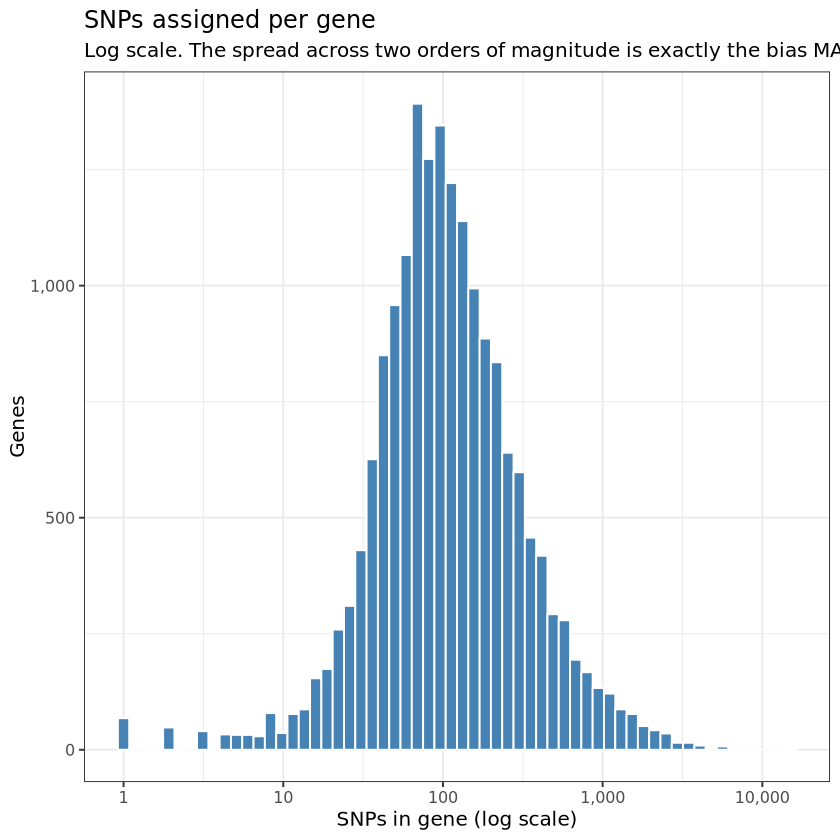

In [28]:
ggplot(annot, aes(x = n_snps)) +
  geom_histogram(bins = 60, fill = "#4682B4", colour = "white") +
  scale_x_log10(labels = label_comma()) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "SNPs assigned per gene",
       subtitle = "Log scale. The spread across two orders of magnitude is exactly the bias MAGMA must correct",
       x = "SNPs in gene (log scale)", y = "Genes") +
  theme_bw(base_size = 12)

::: {.callout-tip}
### Read the output

Around 18,000 of the ~19,400 genes receive at least one SNP; the rest fall in
regions with no QC-passing variants.

The histogram spans two orders of magnitude: some genes get a handful of SNPs,
some get thousands. **This is the whole reason Step 3 is statistically
non-trivial.** If gene p-values were computed by any method that rewards having
more SNPs, this distribution would translate directly into a ranking of genes by
size. Watch for it again in Step 3, where we check explicitly that it has not
happened.
:::

---

## Step 3: Gene Analysis

Combine the SNP p-values within each gene into a single gene p-value, correcting
for LD.


In [35]:
command <- "magma \\
  --bfile      reference_data/g1000_eur/g1000_eur \\
  --gene-annot output/magma/adhd.genes.annot \\
  --pval       output/magma/pval.txt use=SNP,P N=128214 \\
  --out        output/magma/adhd"

output <- system(command, intern=T)
cat(output, sep="\n")

# Output: output/magma/adhd.genes.out   (readable results, one row per gene)
#         output/magma/adhd.genes.raw   (full statistics + gene correlations,
#                                        required as input to Step 4)

Welcome to MAGMA v1.10 (linux/s)
Using flags:
	--bfile reference_data/g1000_eur/g1000_eur
	--gene-annot output/magma/adhd.genes.annot
	--pval output/magma/pval.txt use=SNP,P N=128214
	--out output/magma/adhd

Start time is 11:08:47, Wednesday 12 Aug 2026

Loading PLINK-format data...
Reading file reference_data/g1000_eur/g1000_eur.fam... 503 individuals read
Reading file reference_data/g1000_eur/g1000_eur.bim... 22665064 SNPs read
Preparing file reference_data/g1000_eur/g1000_eur.bed... 

Reading SNP synonyms from file reference_data/g1000_eur/g1000_eur.synonyms (auto-detected)
	read 6016767 mapped synonyms from file, mapping to 3921040 SNPs in the data
	         skipped all synonym entries involved, synonymous SNPs are kept in analysis
	         writing list of detected synonyms in data to supplementary log file
Reading SNP p-values from file output/magma/pval.txt... 
	detected 2 variables in file
	using variable: SNP (SNP id)
	using variable: P (p-value)
	read 6774120 lines from file

::: {.callout-note}
### The arguments, one by one

| Argument | What it does |
|---|---|
| `--bfile` | PLINK-format LD reference. MAGMA reads genotypes here purely to compute SNP-SNP correlations |
| `--gene-annot` | The SNP-to-gene map from Step 2 |
| `--pval ... use=SNP,P` | The p-value file, naming which columns hold the identifier and the p-value |
| `N=128214` | Effective sample size from Step 1. Use `ncol=N` instead if you have a per-SNP N column |
| `--out` | Output prefix. **Both** `.genes.out` and `.genes.raw` are written |

`.genes.raw` looks like an intermediate file but is not disposable: it carries
the gene-gene correlations that Step 4 needs to run a valid competitive test.
Do not delete it.
:::

### Read the results

In [36]:
GENES_OUT <- paste0(OUT_PREFIX, "/adhd.genes.out")

In [37]:
genes <- read.table(GENES_OUT, header = TRUE, stringsAsFactors = FALSE) %>%
  # MAGMA reports Entrez IDs; join the symbols back on so results are readable
  left_join(gene_loc %>% select(GENE, SYMBOL), by = "GENE") %>%
  mutate(GENE = as.character(GENE))

BONF <- 0.05 / nrow(genes)

cat(sprintf("Genes tested                   : %s\n", format(nrow(genes), big.mark = ",")))
cat(sprintf("Bonferroni threshold (0.05/N)  : %.3g\n", BONF))
cat(sprintf("Genome-wide significant genes  : %d\n", sum(genes$P < BONF)))

head(genes, 5)

Genes tested                   : 18,112
Bonferroni threshold (0.05/N)  : 2.76e-06
Genome-wide significant genes  : 56


,GENE,CHR,START,STOP,NSNPS,NPARAM,N,ZSTAT,P,SYMBOL
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,84069,1,891872,920488,7,1,128214,0.65538,0.25611,PLEKHN1
2,84808,1,900579,927473,20,3,128214,1.22680,0.10994,PERM1
3,57801,1,924342,946608,29,3,128214,0.87823,0.18991,HES4
4,9636,1,938847,959920,15,1,128214,0.47696,0.31669,ISG15
5,375790,1,945503,1001499,7,1,128214,0.63903,0.26140,AGRN




::: {.callout-note}
### The columns of `.genes.out`

| Column | Meaning |
|---|---|
| `GENE` | Entrez gene ID |
| `CHR`, `START`, `STOP` | Gene location (hg19) |
| `NSNPS` | Number of SNPs assigned to the gene |
| `NPARAM` | **Effective** number of independent SNPs after accounting for LD. Compare it to `NSNPS`; the gap is the LD correction made visible |
| `N` | Sample size used |
| `ZSTAT` | Gene-level Z statistic. Higher = stronger association. Always positive: a gene has no direction of effect |
| `P` | Gene-level p-value |

The gene-level threshold is Bonferroni across the genes tested, about
**0.05 / 18,000 ≈ 2.7 × 10⁻⁶**. It is *not* 5 × 10⁻⁸: that threshold is
calibrated for a million independent SNP tests, and using it here would be
absurdly conservative.
:::

### Top genes

In [38]:
genes %>%
  arrange(P) %>%
  head(25) %>%
  transmute(SYMBOL,
            GENE, CHR,
            NSNPS,
            NPARAM = round(NPARAM, 1),
            ZSTAT  = round(ZSTAT, 2),
            P      = signif(P, 3),
            Significant = ifelse(P < BONF, "yes", "no"))

,SYMBOL,GENE,CHR,NSNPS,NPARAM,ZSTAT,P,Significant
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,KDM4A,9682,1,106,11,7.42,6.01e-14,yes
2,PTPRF,5792,1,256,12,6.92,2.27e-12,yes
3,ST3GAL3,6487,1,474,23,6.83,4.37e-12,yes
4,CDH8,1006,16,768,44,6.55,2.86e-11,yes
5,XRN2,22803,20,180,14,6.53,3.27e-11,yes
6,DCC,1630,18,4225,106,6.28,1.67e-10,yes
7,SORCS3,22986,10,1773,47,6.23,2.28e-10,yes
8,NKX2-4,644524,20,34,8,6.22,2.49e-10,yes
9,FOXP2,93986,7,835,42,6.08,5.89e-10,yes




### Gene-level Manhattan plot

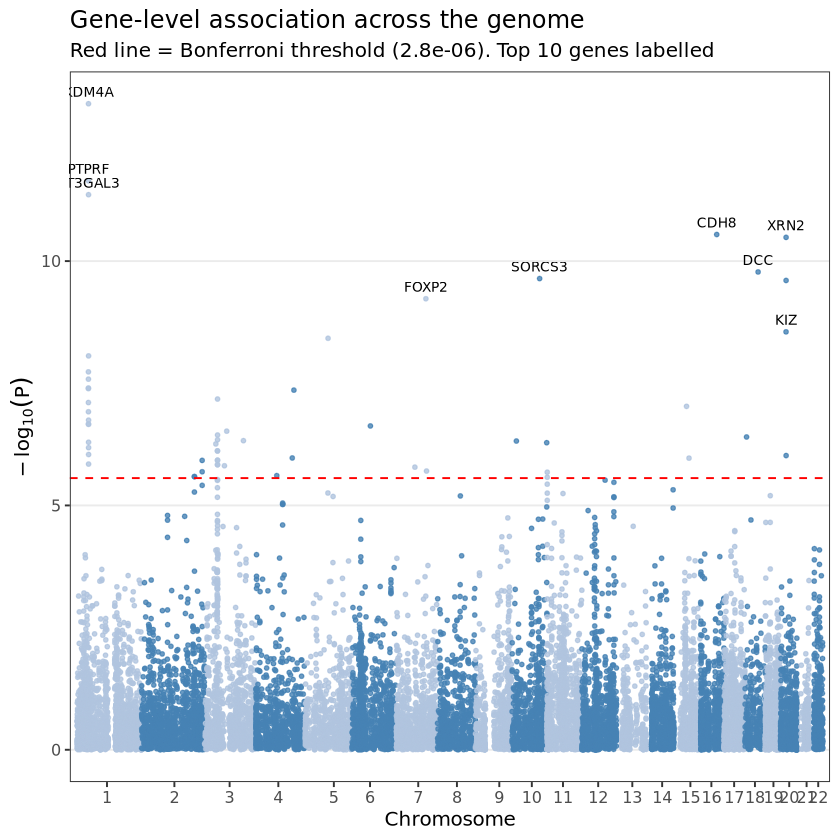

In [39]:
# Build a continuous genome-wide x axis by stacking chromosomes end to end
chr_offsets <- genes %>%
  group_by(CHR) %>%
  summarise(chr_len = max(STOP), .groups = "drop") %>%
  arrange(CHR) %>%
  mutate(offset = cumsum(as.numeric(chr_len)) - as.numeric(chr_len))

plot_dat <- genes %>%
  left_join(chr_offsets, by = "CHR") %>%
  mutate(pos_cum = (START + STOP) / 2 + offset,
         logp    = -log10(P))

axis_dat <- plot_dat %>%
  group_by(CHR) %>%
  summarise(centre = mean(pos_cum), .groups = "drop")

top_labels <- plot_dat %>% arrange(P) %>% head(10)

ggplot(plot_dat, aes(x = pos_cum, y = logp, colour = factor(CHR %% 2))) +
  geom_point(size = 0.9, alpha = 0.8) +
  geom_hline(yintercept = -log10(BONF), colour = "red", linetype = "dashed") +
  geom_text(data = top_labels, aes(label = SYMBOL),
            vjust = -0.7, size = 2.9, colour = "black", check_overlap = TRUE) +
  scale_colour_manual(values = c("#4682B4", "#B0C4DE"), guide = "none") +
  scale_x_continuous(breaks = axis_dat$centre, labels = axis_dat$CHR,
                     expand = expansion(mult = 0.01)) +
  labs(title = "Gene-level association across the genome",
       subtitle = sprintf("Red line = Bonferroni threshold (%.2g). Top 10 genes labelled", BONF),
       x = "Chromosome", y = expression(-log[10](P))) +
  theme_bw(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        panel.grid.major.x = element_blank())



::: {.callout-tip}
### Read the output

Compare this with a standard SNP-level Manhattan plot of the same GWAS. Two
differences matter:

- **The peaks are narrower.** Each locus is now a handful of genes rather than a
  tower of hundreds of correlated SNPs. That is the aggregation doing its job.
- **There are signals here that were not significant at SNP level.** A gene where
  many variants each reach P ≈ 10⁻⁴ can clear the gene-level threshold even
  though no single variant came close to 5 × 10⁻⁸. Recovering that
  sub-threshold, distributed signal is the main reason to run MAGMA at all.
:::

### Did MAGMA actually control for gene size?

This is the check to run every time, and the one most often skipped.

The `method` was set to "gam", but mgcv is not installed.
! Falling back to `method = "lm"`.
ℹ Install mgcv or change the `method` argument to resolve this issue.
`geom_smooth()` using formula = 'y ~ x'


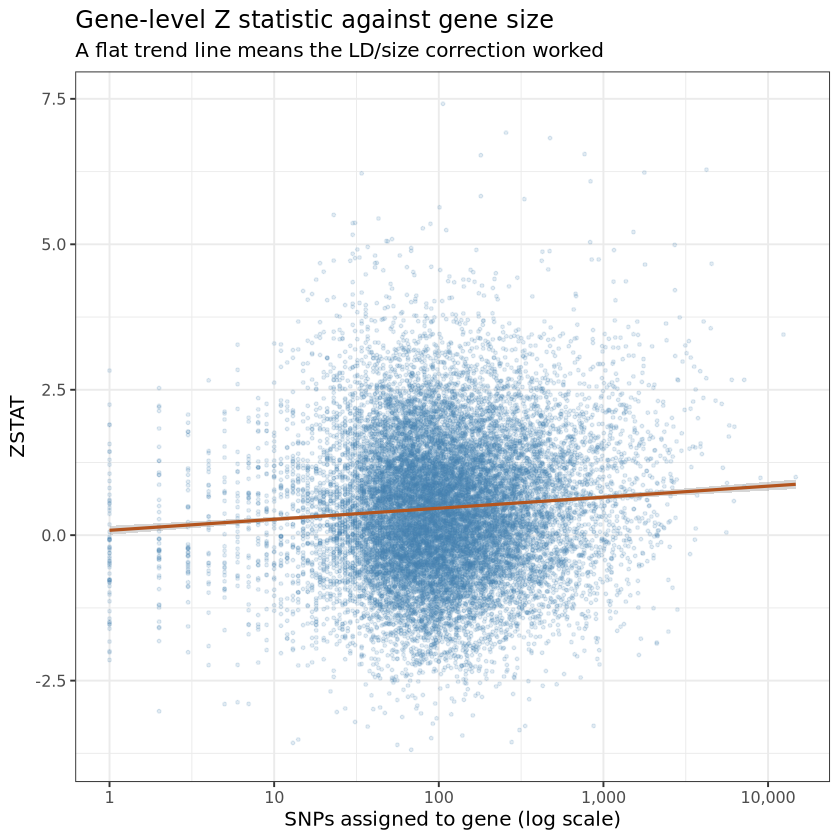

In [40]:
ggplot(genes, aes(x = NSNPS, y = ZSTAT)) +
  geom_point(alpha = 0.15, size = 0.7, colour = "#4682B4") +
  geom_smooth(method = "gam", colour = "#B3541E", se = TRUE, linewidth = 0.9) +
  scale_x_log10(labels = label_comma()) +
  labs(title = "Gene-level Z statistic against gene size",
       subtitle = "A flat trend line means the LD/size correction worked",
       x = "SNPs assigned to gene (log scale)", y = "ZSTAT") +
  theme_bw(base_size = 12)



::: {.callout-tip}
### Read the output

The trend line should be close to **flat**. If bigger genes systematically had
higher Z statistics, your top genes would be a list of the longest genes in the
genome, and the tissue analysis in Step 4 would inherit that bias.

A mild residual upward slope is normal and expected: larger genes really do have
more opportunity to contain causal variation, and MAGMA corrects for the
*statistical* inflation from testing more correlated SNPs, not for that genuine
biological effect.
:::

### Gene-level QQ plot

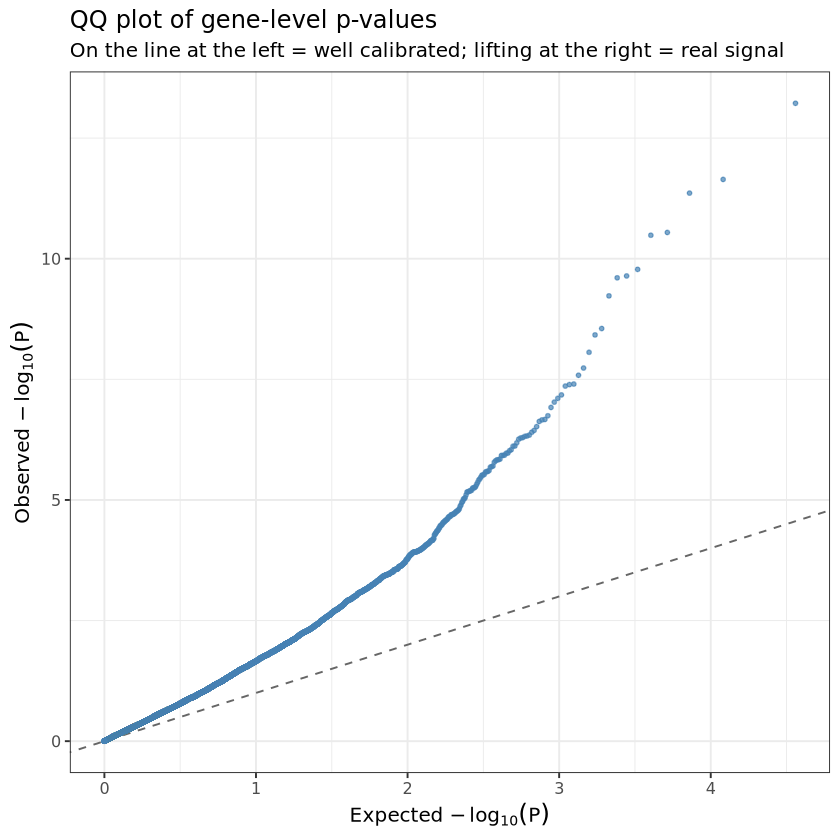

In [41]:
obs <- -log10(sort(genes$P))
exp <- -log10(ppoints(length(obs)))

ggplot(data.frame(exp, obs), aes(x = exp, y = obs)) +
  geom_abline(slope = 1, intercept = 0, colour = "grey40", linetype = "dashed") +
  geom_point(size = 0.9, colour = "#4682B4", alpha = 0.7) +
  labs(title = "QQ plot of gene-level p-values",
       subtitle = "On the line at the left = well calibrated; lifting at the right = real signal",
       x = expression(Expected~-log[10](P)),
       y = expression(Observed~-log[10](P))) +
  theme_bw(base_size = 12)



::: {.callout-tip}
### Read the output

Read it like any QQ plot, but remember that this one is diagnosing **MAGMA**,
not the GWAS. The **left-hand portion sitting on the
diagonal** is the evidence that the LD correction is calibrated. If the bulk of
genes lifted off the line immediately, the LD reference is wrong, most often an
ancestry mismatch, or a `.synonyms` file that failed to load so that most SNPs
went unmatched.
:::

---

## Step 4: Tissue Enrichment

Gene p-values in hand, the question becomes: **do genes specifically expressed in
a particular tissue carry more ADHD signal than genes in general?**


In [42]:
command <- "magma \\
  --gene-results output/magma/adhd.genes.raw \\
  --gene-covar   reference_data/gtex_v8_ts_avg_log2TPM.entrez.dedup.txt \\
  --model        condition-hide=Average direction=greater \\
  --out          output/magma/adhd_tissue"

output <- system(command, intern=T)

cat(output, sep="\n")

# Output: output/magma/adhd_tissue.gsa.out

Welcome to MAGMA v1.10 (linux/s)
Using flags:
	--gene-results output/magma/adhd.genes.raw
	--gene-covar reference_data/gtex_v8_ts_avg_log2TPM.entrez.dedup.txt
	--model condition-hide=Average direction=greater
	--out output/magma/adhd_tissue

Start time is 11:23:08, Wednesday 12 Aug 2026

Reading file output/magma/adhd.genes.raw... 
	18112 genes read from file
Loading gene-level covariates...
Reading file reference_data/gtex_v8_ts_avg_log2TPM.entrez.dedup.txt... 
	detected 55 variables in file (using all)
	found 55 valid gene covariates, for 16966 genes defined in genotype data
Processing missing values...
	found 1146 genes not present in all input files: removing these from analysis
	16966 genes remaining in analysis
Preparing variables for analysis...
	truncating Z-scores 3 points below zero or 6 standard deviations above the mean
	truncating covariate values more than 5 standard deviations from the mean
	total variables available for analysis: 55 gene covariates

Parsing model specif

::: {.callout-important}
### `--model condition-hide=Average direction=greater`

This is the most important line in the session, and the difference between a
result and an artefact.

**`condition-hide=Average`** conditions every tissue test on the average
expression across all tissues, and hides that covariate from the output. Without
it you are asking "are expressed genes associated with ADHD?", to which the
answer is yes for nearly every tissue, and the result is uninterpretable.
With it you are asking "is expression *specific to this tissue* associated with
ADHD?".

**`direction=greater`** makes the test one-sided. The hypothesis is that
*higher* expression in the relevant tissue goes with *stronger* association. A
two-sided test would also flag tissues where the relationship runs backwards,
which has no sensible interpretation here and wastes half your significance
budget.

Run it once without these options and compare (Exercise 1). The difference is
dramatic, and it is the reason a lot of published tissue-enrichment results are
weaker than they look.
:::

### Read the tissue results

In [43]:
OUT_PREFIX

[1] "output/magma"

In [44]:
GSA_OUT <- paste0(OUT_PREFIX, "/adhd_tissue.gsa.out")

In [45]:
gsa <- read.table(GSA_OUT, header = TRUE, comment.char = "#",
                  stringsAsFactors = FALSE)

BONF_TISSUE <- 0.05 / nrow(gsa)

cat(sprintf("Tissues tested       : %d\n", nrow(gsa)))
cat(sprintf("Bonferroni threshold : %.4g\n", BONF_TISSUE))
cat(sprintf("Significant tissues  : %d\n", sum(gsa$P < BONF_TISSUE)))

gsa %>%
  arrange(P) %>%
  head(15) %>%
  transmute(Tissue = VARIABLE,
            NGENES,
            BETA     = round(BETA, 4),
            BETA_STD = round(BETA_STD, 4),
            SE       = round(SE, 4),
            P        = signif(P, 3),
            Significant = ifelse(P < BONF_TISSUE, "yes", "no"))

Tissues tested       : 54
Bonferroni threshold : 0.0009259
Significant tissues  : 11


,Tissue,NGENES,BETA,BETA_STD,SE,P,Significant
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Brain_Cerebellar_Hemisphere,16966,0.0303,0.0607,0.0068,4.61e-06,yes
2,Brain_Frontal_Cortex_BA9,16966,0.0340,0.0624,0.0077,5.11e-06,yes
3,Brain_Cerebellum,16966,0.0307,0.0608,0.0071,6.78e-06,yes
4,Brain_Caudate_basal_ganglia,16966,0.0382,0.0658,0.0088,7.65e-06,yes
5,Brain_Cortex,16966,0.0342,0.0621,0.0080,9.55e-06,yes
6,Brain_Nucleus_accumbens_basa...,16966,0.0362,0.0626,0.0085,1.11e-05,yes
7,Brain_Anterior_cingulate_cor...,16966,0.0339,0.0596,0.0081,1.47e-05,yes
8,Brain_Hypothalamus,16966,0.0377,0.0646,0.0091,1.61e-05,yes
9,Brain_Putamen_basal_ganglia,16966,0.0370,0.0628,0.0090,1.88e-05,yes


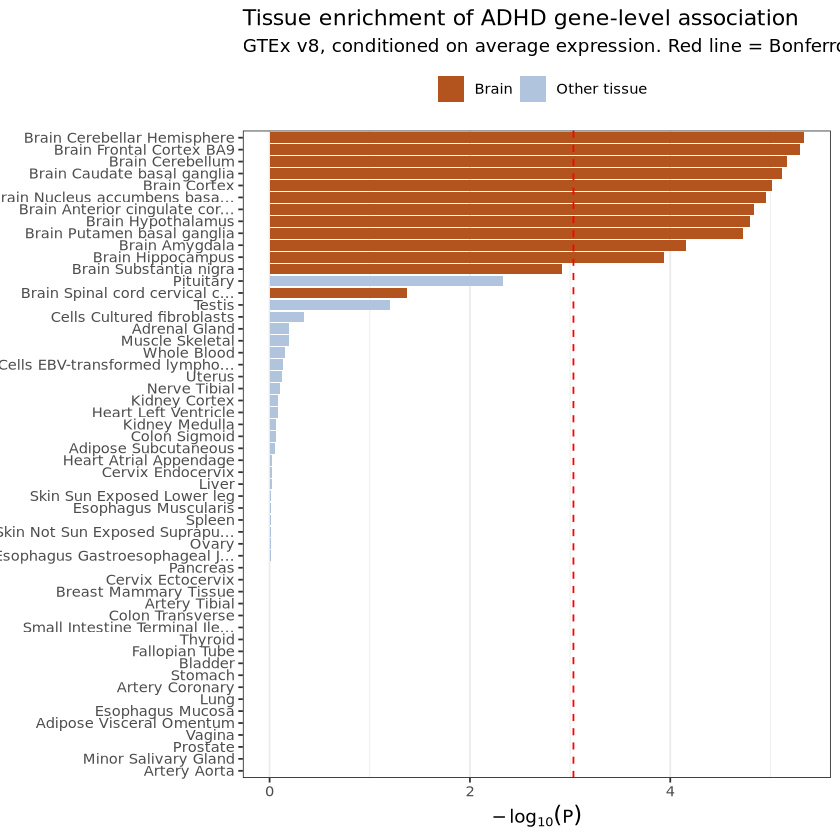

In [46]:
gsa_plot <- gsa %>%
  mutate(logp   = -log10(P),
         tissue = gsub("_", " ", VARIABLE),
         group  = ifelse(grepl("^Brain", VARIABLE), "Brain", "Other tissue"))

ggplot(gsa_plot, aes(x = reorder(tissue, logp), y = logp, fill = group)) +
  geom_col() +
  geom_hline(yintercept = -log10(BONF_TISSUE),
             colour = "red", linetype = "dashed") +
  coord_flip() +
  scale_fill_manual(values = c("Brain" = "#B3541E", "Other tissue" = "#B0C4DE"),
                    name = NULL) +
  labs(title = "Tissue enrichment of ADHD gene-level association",
       subtitle = sprintf("GTEx v8, conditioned on average expression. Red line = Bonferroni (%.2g)",
                          BONF_TISSUE),
       x = NULL, y = expression(-log[10](P))) +
  theme_bw(base_size = 11) +
  theme(legend.position = "top",
        panel.grid.major.y = element_blank())



::: {.callout-tip}
### Read the output

Brain tissues (orange) should dominate the top of the ranking, with several
clearing the Bonferroni line. This is simultaneously a **sanity check**, since a
neurodevelopmental disorder had better implicate brain, and a **result**: it
shows the common-variant signal for ADHD acts through genes with brain-specific
expression, and it points at which brain regions to prioritise.

Three cautions when reading this plot:

- **The 54 tissues are far from independent.** The thirteen brain regions are
  strongly correlated with one another, so Bonferroni is conservative *and* the
  ordering *within* the brain regions is not reliable. Do not claim that
  cerebellum beats cortex because it sits one bar higher.
- **`BETA` matters, not just `P`.** `BETA` is the association between expression
  and gene-level signal; `BETA_STD` puts it on a standardised scale so tissues
  are comparable. A tiny p-value with a negligible beta is a large-sample
  artefact.
- **Testis and whole blood often rank high in GTEx analyses of any trait.**
  Testis expresses an unusually large share of the genome, and whole blood has
  its own expression idiosyncrasies. Treat them with more scepticism than a
  result that matches a known biology.
:::

---

## Step 5 (Extension): Curated Gene Sets

Tissue expression is a *continuous* covariate. MAGMA also runs the classic
**discrete** gene-set test: given a list of genes belonging to a pathway, are
those genes more associated than the rest of the genome?

In [47]:
# Download an Entrez-ID gene set collection from MSigDB, e.g. GO Biological
# Process:  c5.go.bp.v2023.2.Hs.entrez.gmt
#
# GMT format is: SET_NAME <tab> description <tab> gene1 <tab> gene2 ...
# MAGMA expects the set name followed directly by gene IDs, so drop column 2:

system("cut -f1,3- input/c5.go.bp.v2023.2.Hs.entrez.gmt > output/magma/gobp.magma.txt")

command <- "magma \\
  --gene-results output/magma/adhd.genes.raw \\
  --set-annot    output/magma/gobp.magma.txt \\
  --out          output/magma/adhd_gobp"

output <- system(command, intern=T)

cat(output, sep="\n")

# Output: output/magma/adhd_gobp.gsa.out

Welcome to MAGMA v1.10 (linux/s)
Using flags:
	--gene-results output/magma/adhd.genes.raw
	--set-annot output/magma/gobp.magma.txt
	--out output/magma/adhd_gobp

Start time is 11:24:29, Wednesday 12 Aug 2026

Reading file output/magma/adhd.genes.raw... 
	18112 genes read from file
Loading gene-set annotation...
Reading file output/magma/gobp.magma.txt... 
	7647 gene-set definitions read from file
	found 7644 gene sets containing genes defined in genotype data (containing a total of 15290 unique genes)
Preparing variables for analysis...
	truncating Z-scores 3 points below zero or 6 standard deviations above the mean
	truncating covariate values more than 5 standard deviations from the mean
	total variables available for analysis: 7638 gene sets

Parsing model specifications...
Inverting gene-gene correlation matrix...
Performing regression analysis...                                                                                  
	testing direction: one-sided, positive (sets), two-si

::: {.callout-note}
### Competitive vs self-contained tests

The MAGMA gene-set test is **competitive**: the null hypothesis is that genes in
the set are *no more* associated than genes outside it.

A **self-contained** test asks only whether genes in the set are associated at
all, and in a polygenic trait essentially every large gene set passes that,
because the whole genome is mildly enriched. Competitive tests are the ones worth
running, and they are the reason `.genes.raw` (with its gene-gene correlations)
is required rather than just the gene p-values.

Correct for the number of gene sets tested. GO Biological Process contains
several thousand sets, so the Bonferroni threshold is around 10⁻⁵, and MAGMA also
reports an FDR-style correction in the `.gsa.out` header when you request it.
:::

---

## What Can Go Wrong

::: {.callout-caution}
### Genome build mismatch

`NCBI37.3.gene.loc` is hg19. If your summary statistics are hg38, every SNP is
assigned to the wrong gene. There is **no error message**: you get a full,
plausible-looking set of results that is meaningless. Lift over the summary
statistics, or use an hg38 gene location file. Check the build first, every time.
:::

::: {.callout-caution}
### Ancestry mismatch in the LD panel

A European panel with a non-European GWAS produces wrong LD, wrong `NPARAM`, and
wrong gene p-values, silently. Use the matched panel, and for multi-ancestry
meta-analyses be explicit about the limitation in your Methods.
:::

::: {.callout-caution}
### The MHC region (chr6: 25-34 Mb)

Extremely long-range LD makes every gene in the MHC look significant whenever
anything in the region is associated. Standard practice is to exclude the region
entirely, or to retain only a single representative gene, and to say which you
did. Check whether your top hits cluster there before interpreting them.
:::

::: {.callout-caution}
### Tissue analysis without conditioning on average expression

Covered in Step 4 and worth repeating: without `condition-hide=Average` you are
measuring how broadly a gene is expressed, not where it acts. Most tissues will
appear significant, and the result means nothing.
:::

::: {.callout-caution}
### Reading gene-level significance as causality

A significant MAGMA gene is the gene *nearest the signal*, with a 10 kb window.
The causal gene may be hundreds of kilobases away, because regulatory variants
long range. MAGMA prioritises candidates; it does not identify causal genes.
That is what eQTL colocalisation, chromatin interaction data, and the tools later
in this course are for.
:::

::: {.callout-caution}
### Deleting `.genes.raw`

It looks like scratch output. Step 4 cannot run without it, and regenerating it
means repeating the 20-60 minute gene analysis.
:::